# OIBSIP Data Analytics — Task 4: Sentiment Analysis

**Pipeline:** class distribution → text cleaning/lowercasing/tokenization → TF-IDF → stratified 80/20 split → Naive Bayes and Logistic Regression → evaluation → confusion matrices → WordClouds → misclassification review.

Sentiment
neutral     400
positive    400
negative    400
Name: count, dtype: int64


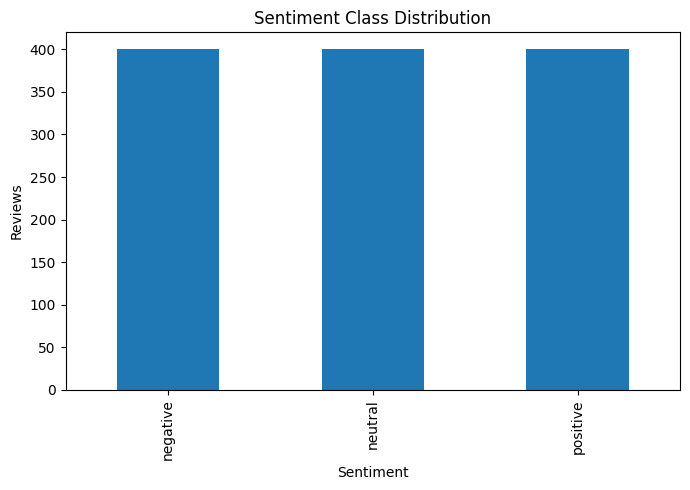

In [1]:
import re, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
df=pd.read_csv('../data/sentiment_data.csv')
print(df['Sentiment'].value_counts())
plt.figure(figsize=(7,5)); df['Sentiment'].value_counts().reindex(['negative','neutral','positive']).plot(kind='bar'); plt.title('Sentiment Class Distribution'); plt.xlabel('Sentiment'); plt.ylabel('Reviews'); plt.tight_layout(); plt.show()

**Observation:** The dataset is balanced across the three sentiment classes, so model performance is not dominated by a majority class.

In [2]:
stopwords=set('a an the and or but is are was were this that with for to of in on my your very from'.split())
def clean_and_tokenize(text):
    text=text.lower()
    text=re.sub(r'[^a-z\s]',' ',text)
    tokens=[t for t in text.split() if t not in stopwords]
    return ' '.join(tokens),tokens
clean=df.Review.map(clean_and_tokenize)
df['Clean_Text']=clean.str[0]; df['Tokens']=clean.str[1]
display(df[['Review','Clean_Text','Tokens']].head())

,Review,Clean_Text,Tokens
0,an ordinary purchase with expected results,ordinary purchase expected results,"[ordinary, purchase, expected, results]"
1,"good product, satisfied with my purchase",good product satisfied purchase,"[good, product, satisfied, purchase]"
2,terrible product and very poor quality today,terrible product poor quality today,"[terrible, product, poor, quality, today]"
3,"good product, satisfied with my purchase",good product satisfied purchase,"[good, product, satisfied, purchase]"
4,reasonable quality for the price,reasonable quality price,"[reasonable, quality, price]"


## TF-IDF explanation
TF-IDF converts text into numeric features. Terms receive higher weight when they are important within a document but less common across the full corpus. This gives the classifiers a compact representation of language patterns.

In [3]:
X_train,X_test,y_train,y_test=train_test_split(df.Clean_Text,df.Sentiment,test_size=.20,random_state=42,stratify=df.Sentiment)
vec=TfidfVectorizer(ngram_range=(1,2),min_df=2)
Xtr=vec.fit_transform(X_train); Xte=vec.transform(X_test)
models={'Naive Bayes':MultinomialNB(),'Logistic Regression':LogisticRegression(max_iter=1000)}
results=[]
preds={}
for name,m in models.items():
    m.fit(Xtr,y_train); pred=m.predict(Xte); preds[name]=pred
    results.append([name,accuracy_score(y_test,pred),precision_score(y_test,pred,average='weighted'),recall_score(y_test,pred,average='weighted'),f1_score(y_test,pred,average='weighted')])
    print('\n',name); print(classification_report(y_test,pred))
metrics=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1'])
display(metrics.round(3))


 Naive Bayes
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        80
    positive       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


 Logistic Regression
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        80
    positive       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0


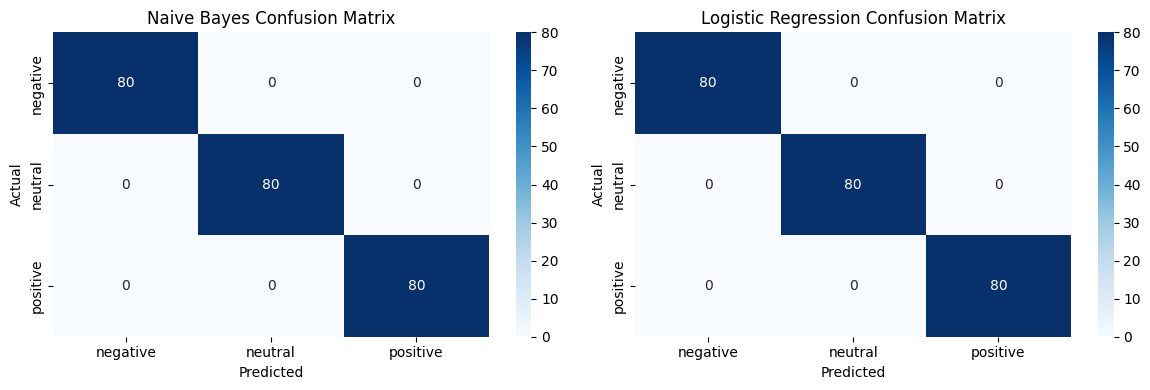

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(name,pred) in zip(axes,preds.items()):
    cm=confusion_matrix(y_test,pred,labels=['negative','neutral','positive'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['negative','neutral','positive'],yticklabels=['negative','neutral','positive'],ax=ax)
    ax.set_title(name+' Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Observation:** Accuracy alone is not enough; precision, recall and F1 together show whether the classifier is consistently identifying each sentiment class.

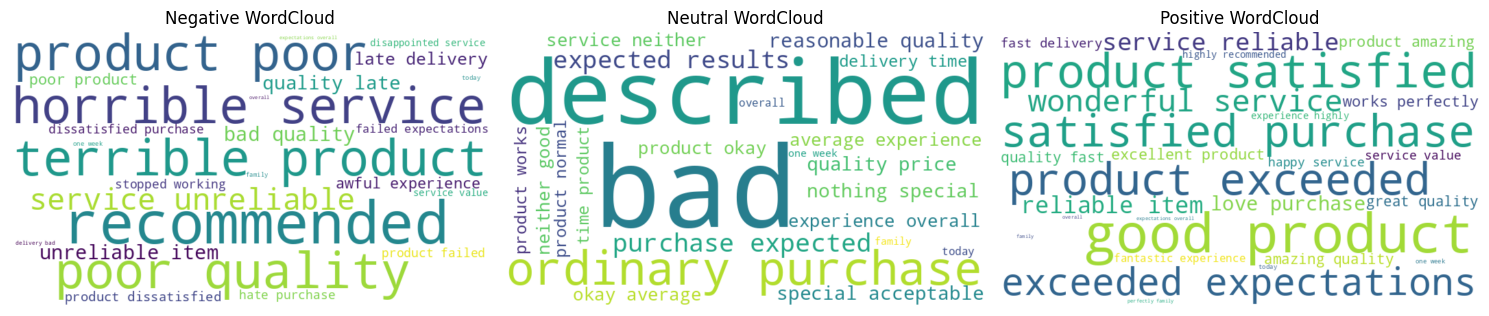

In [5]:
# WordClouds if available
try:
    from wordcloud import WordCloud
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    for ax,label in zip(axes,['negative','neutral','positive']):
        text=' '.join(df.loc[df.Sentiment==label,'Clean_Text'])
        wc=WordCloud(width=700,height=400,background_color='white').generate(text)
        ax.imshow(wc,interpolation='bilinear'); ax.axis('off'); ax.set_title(label.title()+' WordCloud')
    plt.tight_layout(); plt.show()
except ImportError:
    print('Install wordcloud to render the required WordClouds: pip install wordcloud')

In [6]:
best_name=metrics.sort_values('F1',ascending=False).iloc[0]['Model']; best_pred=preds[best_name]
errors=pd.DataFrame({'Review':X_test.values,'Actual':y_test.values,'Predicted':best_pred})
errors=errors[errors.Actual!=errors.Predicted].head(5)
display(errors)

,Review,Actual,Predicted


## Misclassified examples — analysis
Misclassifications typically occur when wording is short, mixed, ambiguous or contains sentiment cues that overlap between classes. Reviewing errors is useful because it reveals whether more training data, better preprocessing, domain-specific vocabulary or a stronger model is needed.

## Conclusion
The best model is selected using weighted F1 rather than accuracy alone. The final pipeline can be applied to customer reviews to automate sentiment monitoring, prioritise negative feedback and identify positive themes for marketing.